# Aprendizaje Automático II - Trabajo Práctico N°2

- Antuña, Franco (A-4637/1)
- Asad, Gonzalo (A-4595/1)
- Castells, Sergio (C-7334/2)

----------------

# Preparación del Entorno

Importar librerías

In [ ]:
import os
import pathlib
import random

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow.keras import layers
from tensorflow.keras import models
from IPython import display
from pathlib import Path

# Set the seed value for experiment reproducibility.
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

Establecer GPU por defecto en caso de estar disponible.

In [ ]:
# Configurar para que TensorFlow utilice la GPU por defecto
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Configurar para que TensorFlow asigne memoria dinámicamente
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        # Especificar la GPU por defecto
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Manejar error
        print(e)

1 Physical GPUs, 1 Logical GPUs


# Problema 1

## Preparación del Dataset

Descarga del dataset

In [ ]:
# Descargar el dataset desde TFDS
ds, info = tfds.load('spoken_digit', split='train', as_supervised=True, with_info=True)

# Ruta donde guardar los archivos WAV
data_dir = Path("/content/spoken_digit_audio")
data_dir.mkdir(parents=True, exist_ok=True)

# Guardar los audios por clase
for i, (audio, label) in enumerate(tfds.as_numpy(ds)):
    class_dir = data_dir / str(label)
    class_dir.mkdir(exist_ok=True)

    file_path = class_dir / f"{i}.wav"

    # Convertir audio a float32 y normalizar
    audio_float = tf.cast(audio, tf.float32) / 32768.0

    # Reformatear audio para tf.audio.encode_wav agregando una dimensión
    audio_reshaped = tf.expand_dims(audio_float, axis=-1)

    # Codificar y escribir los archivos WAV
    # Usar tf.io.write_file para escribir los datos WAV codificados
    # wav_data = tf.audio.encode_wav(audio_reshaped, 16000)
    wav_data = tf.audio.encode_wav(audio_reshaped, 8000)
    tf.io.write_file(str(file_path), wav_data)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/spoken_digit/incomplete.03HDDA_1.0.9/spoken_digit-train.tfrecord*...:   0%…

Dataset spoken_digit downloaded and prepared to /root/tensorflow_datasets/spoken_digit/1.0.9. Subsequent calls will reuse this data.


División del dataset en training y validation.

Los clips de audio duran 1 segundo o menos, a 8kHz. El parámetro `output_sequence_length=8000` agrega padding para que todos los ejemplos duren exactamente 1 segundo (y trunca los que son más largos).

In [ ]:
train_ds, val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory=str(data_dir),
    batch_size=64,
    validation_split=0.2,
    seed=0,
    output_sequence_length=8000,
    subset='both',
    shuffle=True
)

label_names = np.array(train_ds.class_names)
print("label names:", label_names)

Found 2500 files belonging to 10 classes.
Using 2000 files for training.
Using 500 files for validation.
label names: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


Los clips de audio tiene shape `(batch, samples, channels)` y los labels son enteros.

In [ ]:
train_ds.element_spec

(TensorSpec(shape=(None, 8000, None), dtype=tf.float32, name=None),
 TensorSpec(shape=(None,), dtype=tf.int32, name=None))

El dataset contiene un solo canal de audio por clip, usamos `tf.squeeze` para descartar el eje extra.

In [ ]:
def squeeze(audio, labels):
  audio = tf.squeeze(audio, axis=-1)
  return audio, labels

train_ds = train_ds.map(squeeze, tf.data.AUTOTUNE)
val_ds = val_ds.map(squeeze, tf.data.AUTOTUNE)

In [ ]:
for example_audio, example_labels in train_ds.take(1):
  print(example_audio.shape)
  print(example_labels.shape)

(64, 8000)
(64,)


## Análisis Exploratorio

Analizamos si el dataset se encuentra balanceado, para un correcto entrenamiento del modelo (sin sesgo fuerte).

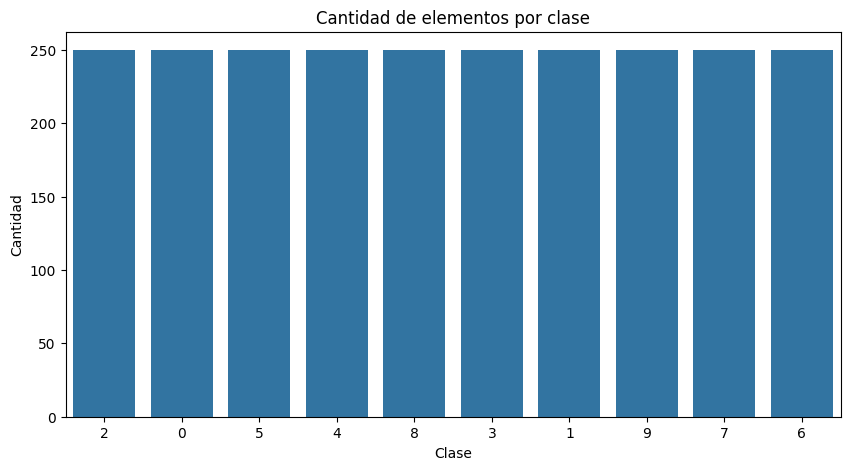


La clase con menos elementos es 0 con 250 elementos.
La clase con más elementos es 9 con 250 elementos.
La diferencia de elementos entre las clases mayoritaria y minoritaria es del 0.00%


In [ ]:
def contar_elementos(ruta):
    """
    Cuenta el número de archivos y carpetas en una carpeta y sus subcarpetas.
    Args:
        ruta: La ruta de la carpeta.

    Returns:
        Un entero que representa el número total de elementos.
    """
    dict_content = {}

    for dirpath, dirnames, filenames in os.walk(ruta):
      for dir in dirnames:
          ruta_dir = ruta + "/" + dir
          dict_content[dir] = len(os.listdir(ruta_dir))
    return dict_content

ruta_de_la_carpeta = "/content/spoken_digit_audio"
numero_de_elementos = contar_elementos(ruta_de_la_carpeta)

plt.figure(figsize=(10,5))
sns.barplot(data = numero_de_elementos)
plt.title("Cantidad de elementos por clase")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()

print("\nLa clase con menos elementos es", min(numero_de_elementos), "con", numero_de_elementos[min(numero_de_elementos)], "elementos.")
print("La clase con más elementos es", max(numero_de_elementos), "con", numero_de_elementos[max(numero_de_elementos)], "elementos.")
porc = 100 - numero_de_elementos[min(numero_de_elementos)]/numero_de_elementos[max(numero_de_elementos)]*100
print(f"La diferencia de elementos entre las clases mayoritaria y minoritaria es del {porc:.2f}%")

En vista que el modelo está balanceado, imprimimos en pantalla la forma de onda para visualizar algunos ejemplos.

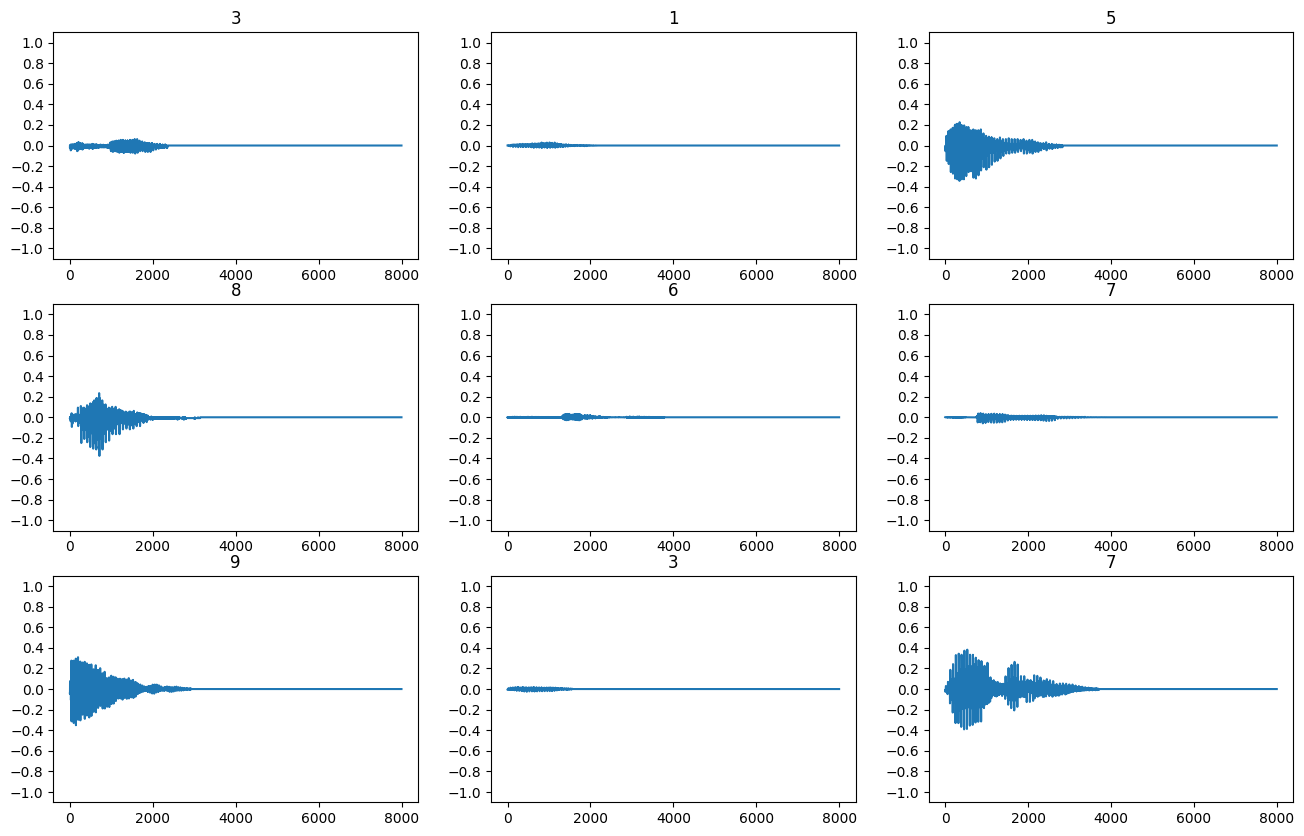

In [ ]:
plt.figure(figsize=(16, 10))
rows = 3
cols = 3
n = rows * cols
for i in range(n):
  plt.subplot(rows, cols, i+1)
  audio_signal = example_audio[i]
  plt.plot(audio_signal)
  plt.title(label_names[example_labels[i]])
  plt.yticks(np.arange(-1.2, 1.2, 0.2))
  plt.ylim([-1.1, 1.1])

Las formas de onda en el conjunto de datos están representadas en el dominio del tiempo. A continuación, se transforman las formas de onda de señales del dominio del tiempo a señales del dominio tiempo-frecuencia para convertir las formas de onda en espectrogramas, que muestran cambios de frecuencia a lo largo del tiempo y pueden ser representados como imágenes 2D.

In [ ]:
def get_spectrogram(waveform):
  # Convertir la forma de onda a un espectrograma a través de una STFT.
  spectrogram = tf.signal.stft(
      waveform, frame_length=255, frame_step=128)
  # Obtener la magnitud de la STFT.
  spectrogram = tf.abs(spectrogram)
  # Añadir una dimensión `channels`, para que el espectrograma pueda ser utilizado
  # como datos de entrada tipo imagen con capas de convolución (que esperan
  # forma (`tamaño_batch`, `altura`, `ancho`, `canales`).
  spectrogram = spectrogram[..., tf.newaxis]
  return spectrogram

Para verificar que el dataset fue cargado correctamente, se imprimen las formas de uno de los ejemplos de la forma de onda tesorizada y su espectrograma correspondiente, junto con la reproducción de su audio original.

In [ ]:
for i in range(3):
  label = label_names[example_labels[i]]
  waveform = example_audio[i]
  spectrogram = get_spectrogram(waveform)

  print('Label:', label)
  print('Waveform shape:', waveform.shape)
  print('Spectrogram shape:', spectrogram.shape)
  print('Audio playback')
  display.display(display.Audio(waveform, rate=8000))

Label: 3
Waveform shape: (8000,)
Spectrogram shape: (61, 129, 1)
Audio playback


Label: 1
Waveform shape: (8000,)
Spectrogram shape: (61, 129, 1)
Audio playback


Label: 5
Waveform shape: (8000,)
Spectrogram shape: (61, 129, 1)
Audio playback


Definimos luego una función para imprimir en pantalla el espectrograma.

In [ ]:
def plot_spectrogram(spectrogram, ax):
  if len(spectrogram.shape) > 2:
    assert len(spectrogram.shape) == 3
    spectrogram = np.squeeze(spectrogram, axis=-1)
  # Convertir las frecuencias a escala logarítmica y transponer, para que el tiempo esté
  # representado en el eje x (columnas).
  # Añadir un epsilon para evitar tomar el logaritmo de cero.
  log_spec = np.log(spectrogram.T + np.finfo(float).eps)
  height = log_spec.shape[0]
  width = log_spec.shape[1]
  X = np.linspace(0, np.size(spectrogram), num=width, dtype=int)
  Y = range(height)
  ax.pcolormesh(X, Y, log_spec)

Imprimimos la forma de onda junto con su espectrograma de un ejemplo.

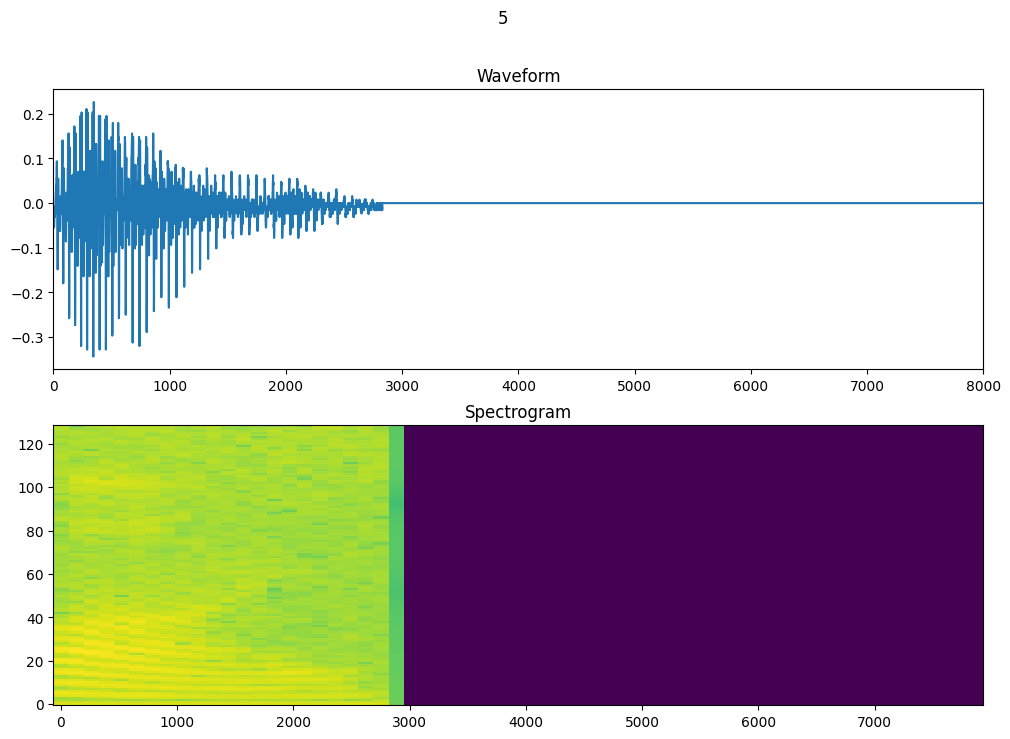

In [ ]:
fig, axes = plt.subplots(2, figsize=(12, 8))
timescale = np.arange(waveform.shape[0])
axes[0].plot(timescale, waveform.numpy())
axes[0].set_title('Waveform')
axes[0].set_xlim([0, 8000])

plot_spectrogram(spectrogram.numpy(), axes[1])
axes[1].set_title('Spectrogram')
plt.suptitle(label.title())
plt.show()

Ahora creamos un dataset de espectrogramas utilizando la función definida.

In [ ]:
def make_spec_ds(ds):
  return ds.map(
      map_func=lambda audio,label: (get_spectrogram(audio), label),
      num_parallel_calls=tf.data.AUTOTUNE)

In [ ]:
train_spectrogram_ds = make_spec_ds(train_ds)
val_spectrogram_ds = make_spec_ds(val_ds)

Y examinamos el espectrograma para distintos ejemplos del dataset.

In [ ]:
for example_spectrograms, example_spect_labels in train_spectrogram_ds.take(1):
  break

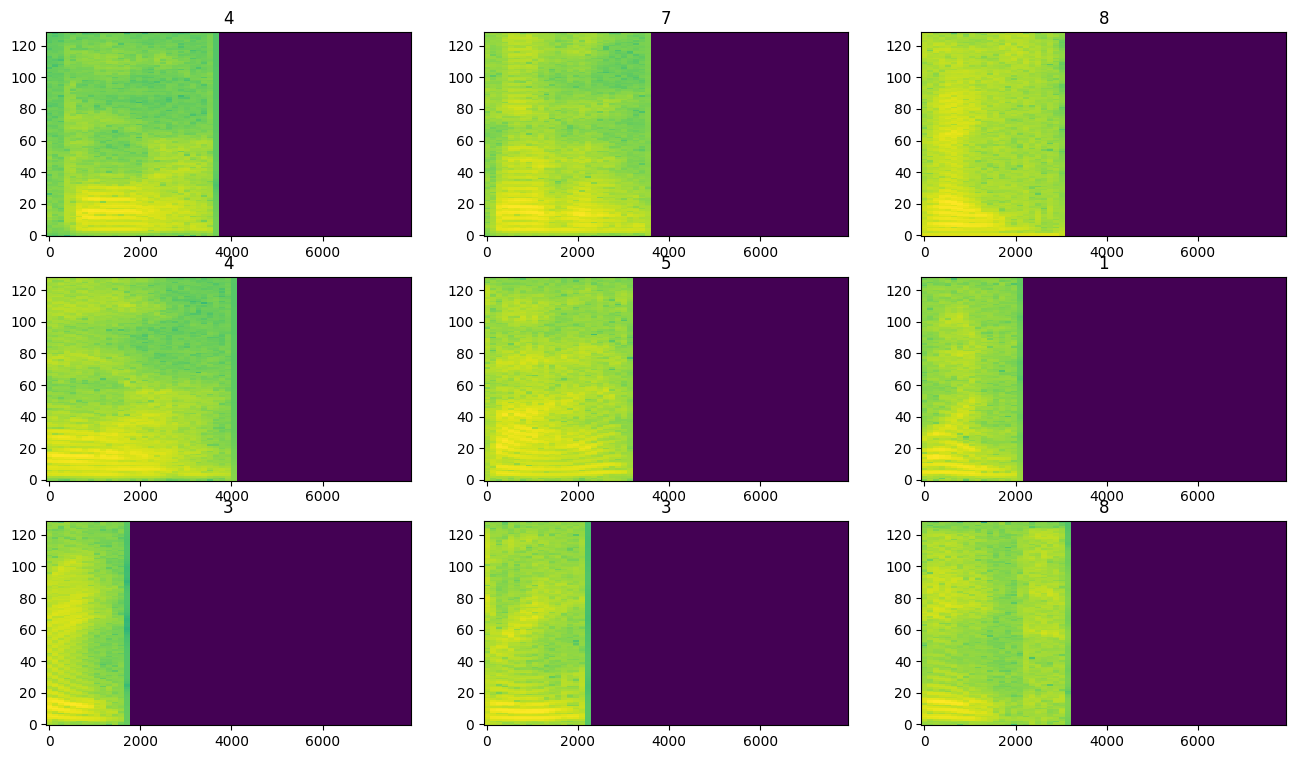

In [ ]:
rows = 3
cols = 3
n = rows*cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 9))

for i in range(n):
    r = i // cols
    c = i % cols
    ax = axes[r][c]
    plot_spectrogram(example_spectrograms[i].numpy(), ax)
    ax.set_title(label_names[example_spect_labels[i].numpy()])

plt.show()

## Modelado

Optimizamos la carga del dataset

In [ ]:
train_spectrogram_ds = train_spectrogram_ds.cache().shuffle(10000).prefetch(tf.data.AUTOTUNE)
val_spectrogram_ds = val_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)

### CNN

#### Construir y Entrenar el Modelo

Para el modelo, se utilizará una red neuronal convolucional simple (CNN), ya que se han transformado los archivos de audio en imágenes de espectrograma.

El modelo `tf.keras.Sequential` utilizará las siguientes capas de preprocesamiento de Keras:

- `tf.keras.layers.Resizing`: para reducir la resolución de la entrada y permitir que el modelo entrene más rápido.
- `tf.keras.layers.Normalization`: para normalizar cada píxel en la imagen basándose en su media y desviación estándar.

Para la capa de Normalización, primero se debe llamar a su método `adapt` en los datos de entrenamiento para calcular las estadísticas agregadas (es decir, la media y la desviación estándar).

In [ ]:
input_shape = example_spectrograms.shape[1:]
print('Input shape:', input_shape)
num_labels = len(label_names)

# Instanciar la capa `tf.keras.layers.Normalization`.
norm_layer = layers.Normalization()
# Ajustar el estado de la capa a los espectrogramas
# con `Normalization.adapt`.
norm_layer.adapt(data=train_spectrogram_ds.map(map_func=lambda spec, label: spec))

model_cnn = models.Sequential([
    layers.Input(shape=input_shape),
    # Cambiar tamaño de la entrada
    layers.Resizing(32, 32),
    # Normalizar,
    norm_layer,
    layers.Conv2D(32, 3, activation='relu'),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_labels),
])

model_cnn.summary()

Input shape: (61, 129, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 32, 32, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,869 (6.20 MB)

 Trainable params: 1,625,866 (6.20 MB)

 Non-trainable params: 3 (16.00 B)

Compilamos el modelo:

In [ ]:
model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

Entrenamos durante 50 epochs con early stopping:

In [ ]:
EPOCHS = 50
history_cnn = model_cnn.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=EPOCHS,
    callbacks=tf.keras.callbacks.EarlyStopping(verbose=1, patience=5),
)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - accuracy: 0.2942 - loss: 1.9914 - val_accuracy: 0.6220 - val_loss: 1.2425
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6096 - loss: 1.2140 - val_accuracy: 0.7320 - val_loss: 0.8526
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6991 - loss: 0.9457 - val_accuracy: 0.7780 - val_loss: 0.7202
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7603 - loss: 0.7542 - val_accuracy: 0.8580 - val_loss: 0.5768
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7924 - loss: 0.6424 - val_accuracy: 0.8940 - val_loss: 0.4557
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8492 - loss: 0.5185 - val_accuracy: 0.8940 - val_loss: 0.4439
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8772 - loss: 0.4104 - val_accuracy: 0.8960 - val_loss: 0.3597
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8690 - loss: 0.4418 - val_accuracy: 0.9200 - val_lo

Imprimimos en pantalla los resultados:

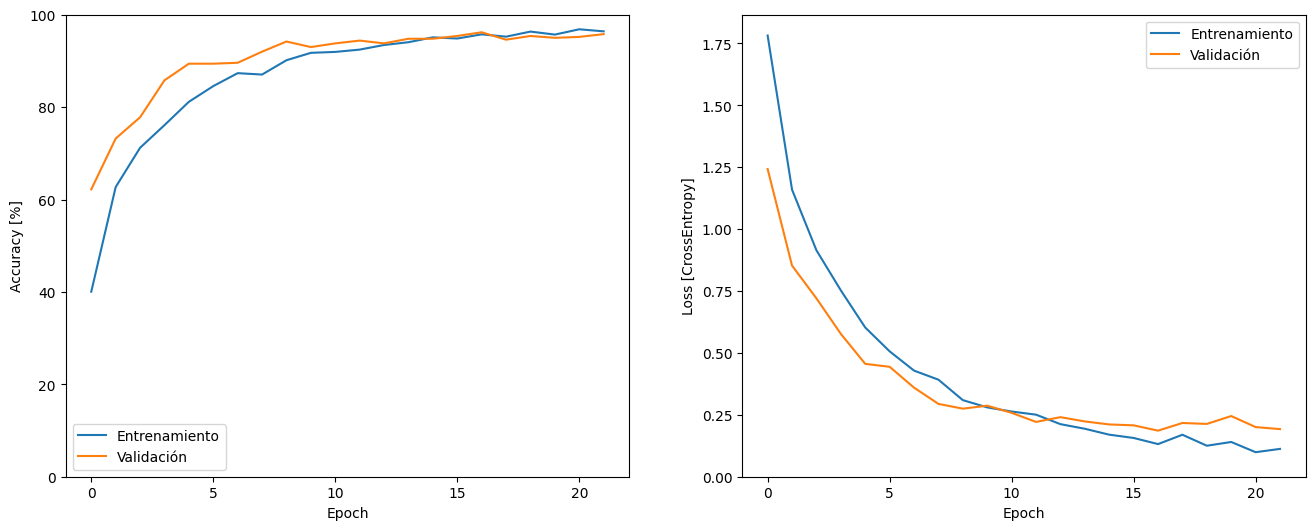

In [ ]:
metrics = history_cnn.history

plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.plot(history_cnn.epoch, 100*np.array(metrics['accuracy']), 100*np.array(metrics['val_accuracy']))
plt.legend(['Entrenamiento', 'Validación'])
plt.ylim([0, 100])
plt.xlabel('Epoch')
plt.ylabel('Accuracy [%]')

plt.subplot(1,2,2)
plt.plot(history_cnn.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['Entrenamiento', 'Validación'])
plt.ylim([0, max(plt.ylim())])
plt.xlabel('Epoch')
plt.ylabel('Loss [CrossEntropy]')

plt.show()

Utilizamos una matriz de confusión para verificar qué tan bien clasificó el modelo cada uno de los comandos en el conjunto de prueba:

In [ ]:
y_pred_cnn = model_cnn.predict(val_spectrogram_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step


In [ ]:
y_pred_cnn = tf.argmax(y_pred_cnn, axis=1)

In [ ]:
y_true = tf.concat(list(val_spectrogram_ds.map(lambda s,lab: lab)), axis=0)

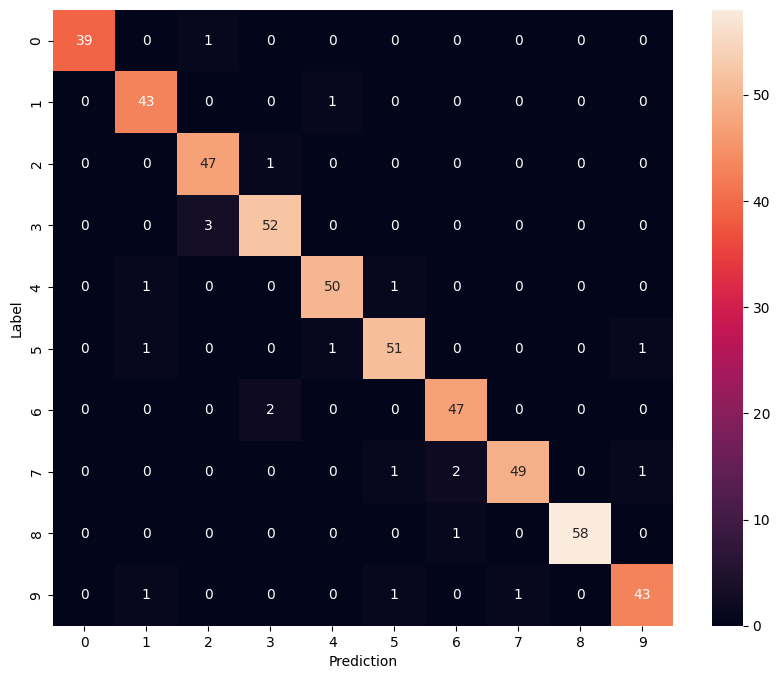

In [ ]:
confusion_mtx_cnn = tf.math.confusion_matrix(y_true, y_pred_cnn)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx_cnn,
            xticklabels=label_names,
            yticklabels=label_names,
            annot=True, fmt='g')
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()

#### Inferir sobre un archivo de audio

Finalmente, inferimos sobre un archivo de audio (en este caso tomamos un archivo del dataset arbitrario, podría ser un archivo .wav completamente nuevo).

In [ ]:
def predecir_audio_aleatorio(model, data_dir, label_names, get_spectrogram_fn, sample_rate=8000):
    # Lista todos los archivos de audio usando un patrón relativo y recursivo
    audio_files = list(data_dir.glob('**/*.wav'))
    if not audio_files:
        print("No se encontraron archivos de audio en el directorio.")
        return

    # Selecciona un archivo aleatorio
    random_audio_file = random.choice(audio_files)
    print(f"Archivo seleccionado: {random_audio_file}")

    # Carga el audio
    audio_binary = tf.io.read_file(str(random_audio_file))
    waveform, _ = tf.audio.decode_wav(audio_binary, desired_channels=1, desired_samples=sample_rate)
    waveform = tf.squeeze(waveform, axis=-1)

    # Convertir a espectrograma
    spectrogram = get_spectrogram_fn(waveform)
    spectrogram = spectrogram[tf.newaxis, ...]  # Añade dimensión batch

    # Predicción
    prediction = model(spectrogram)
    prediction_probs = tf.nn.softmax(prediction[0]).numpy()
    predicted_index = np.argmax(prediction_probs)
    predicted_label = label_names[predicted_index]

    # Visualización
    plt.figure(figsize=(6,4))
    plt.bar(range(len(label_names)), prediction_probs)
    plt.xticks(range(len(label_names)), label_names)
    plt.ylabel("Confianza")
    plt.xlabel("Clase")

    # Etiqueta real
    try:
        # Assumes the directory name is the label
        actual_label = random_audio_file.parent.name
        plt.title(f'Predicción: {predicted_label} - Real: {actual_label}')
    except Exception as e:
        plt.title(f'Predicción: {predicted_label}')

    plt.show()

    # Reproducir el audio
    display.display(display.Audio(waveform, rate=sample_rate))

Archivo seleccionado: /content/spoken_digit_audio/7/575.wav


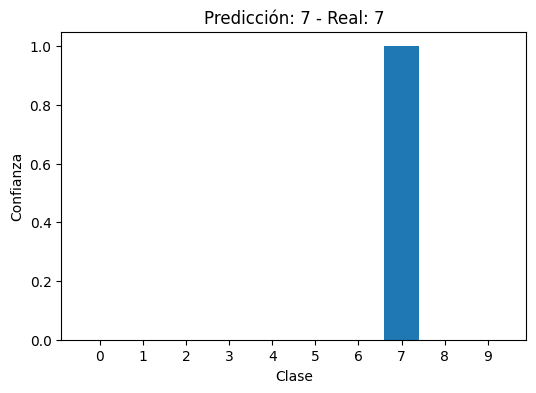

In [ ]:
predecir_audio_aleatorio(model_cnn, data_dir, label_names, get_spectrogram)

### RNN

#### Construir y Entrenar el Modelo

Para el modelo, se utilizará una red neuronal recurrente (RNN).

El modelo `tf.keras.Sequential` utilizará las siguientes capas de preprocesamiento de Keras:

- `tf.keras.layers.LSTM`: como capa recurrente.
- `tf.keras.layers.Normalization`: para normalizar cada píxel en la imagen basándose en su media y desviación estándar.

Para la capa de Normalización, primero se debe llamar a su método `adapt` en los datos de entrenamiento para calcular las estadísticas agregadas (es decir, la media y la desviación estándar).

In [ ]:
input_shape = example_spectrograms.shape[1:]
print('Input shape:', input_shape)
num_labels = len(label_names)

# Instanciar la capa `tf.keras.layers.Normalization`.
norm_layer = layers.Normalization()
# Ajustar el estado de la capa a los espectrogramas
# con `Normalization.adapt`.
norm_layer.adapt(data=train_spectrogram_ds.map(map_func=lambda spec, label: spec))

# Proporcionemos una arquitectura CNN-LSTM más típica para espectrogramas
# Este enfoque trata el espectrograma como una secuencia de pasos de tiempo, donde cada
# paso de tiempo es un segmento a través de los depósitos de frecuencia.
# Aplica Conv1D a través de la dimensión de frecuencia para cada paso de tiempo.

# Obtener la forma del espectrograma sin la dimensión del canal para Conv1D
spectrogram_shape_for_rnn = example_spectrograms.shape[1:3] # (61, 129) -> (pasos de tiempo, depósitos de frecuencia)
print('Spectrogram shape for RNN (timesteps, features):', spectrogram_shape_for_rnn)

# Definir el modelo Sequential
model_rnn = models.Sequential()

# Añadir la capa de entrada y capas de preprocesamiento
model_rnn.add(layers.Input(shape=input_shape))
model_rnn.add(norm_layer) # Normalizar el espectrograma de entrada

# Aplicar capas Conv2D a través de todo el espectrograma para extracción de características
model_rnn.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
model_rnn.add(layers.MaxPooling2D((2, 2), padding='same'))
model_rnn.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model_rnn.add(layers.MaxPooling2D((2, 2), padding='same'))
model_rnn.add(layers.BatchNormalization())

# Obtener la forma de salida de la parte convolucional DESPUÉS de añadir las capas
conv_output_shape = model_rnn.output_shape # (None, nueva_altura, nuevo_ancho, nuevos_filtros)
print("Shape after Conv layers:", conv_output_shape)

# Calcular las dimensiones para la capa Reshape
# La forma debe ser (tamaño_batch, pasos_tiempo, características)
# timesteps = nueva_altura
# features = nuevo_ancho * nuevos_filtros
timesteps = conv_output_shape[1]
features = conv_output_shape[2] * conv_output_shape[3]
print("Timesteps:", timesteps, ", Features:", features)

# Añadir la capa Reshape para crear una secuencia
model_rnn.add(layers.Reshape((timesteps, features)))
model_rnn.add(layers.Dropout(0.5))

# Añadir la capa recurrente (LSTM)
model_rnn.add(layers.LSTM(64, return_sequences=False, dropout=0.5))

# Capas densas para la salida
model_rnn.add(layers.Dense(64, activation='relu'))
model_rnn.add(layers.Dropout(0.5))
model_rnn.add(layers.Dense(num_labels, activation='softmax')) # Usar softmax para pérdida de clasificación multiclase


model_rnn.summary()

Input shape: (61, 129, 1)
Spectrogram shape for RNN (timesteps, features): (61, 129)
Shape after Conv layers: (None, 16, 33, 64)
Timesteps: 16 , Features: 2112


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 61, 129, 1)     │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 61, 129, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 31, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 31, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 33, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 33, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 16, 2112)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 2112)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │       557,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 581,197 (2.22 MB)

 Trainable params: 581,066 (2.22 MB)

 Non-trainable params: 131 (528.00 B)

Compilamos el modelo:

In [ ]:
model_rnn.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

Entrenamos durante 50 epochs con early stopping:

In [ ]:
EPOCHS = 50
history_rnn = model_rnn.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=EPOCHS,
    callbacks=tf.keras.callbacks.EarlyStopping(verbose=1, patience=8),
)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/nn.py:708: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.1195 - loss: 2.3301 - val_accuracy: 0.0700 - val_loss: 2.3044
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1549 - loss: 2.2476 - val_accuracy: 0.1200 - val_loss: 2.2676
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.2220 - loss: 2.0721 - val_accuracy: 0.2020 - val_loss: 2.0965
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.2841 - loss: 1.8357 - val_accuracy: 0.2660 - val_loss: 1.8811
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3777 - loss: 1.5648 - val_accuracy: 0.3300 - val_loss: 1.6945
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5364 - loss: 1.1916 - val_accuracy: 0.5020 - val_loss: 1.4936
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6005 - loss: 1.0129 - val_accuracy: 0.4720 - val_loss: 1.3200
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6920 - loss: 0.8111 - val_accuracy: 0.5780 - val_loss: 1.

Imprimimos en pantalla los resultados:

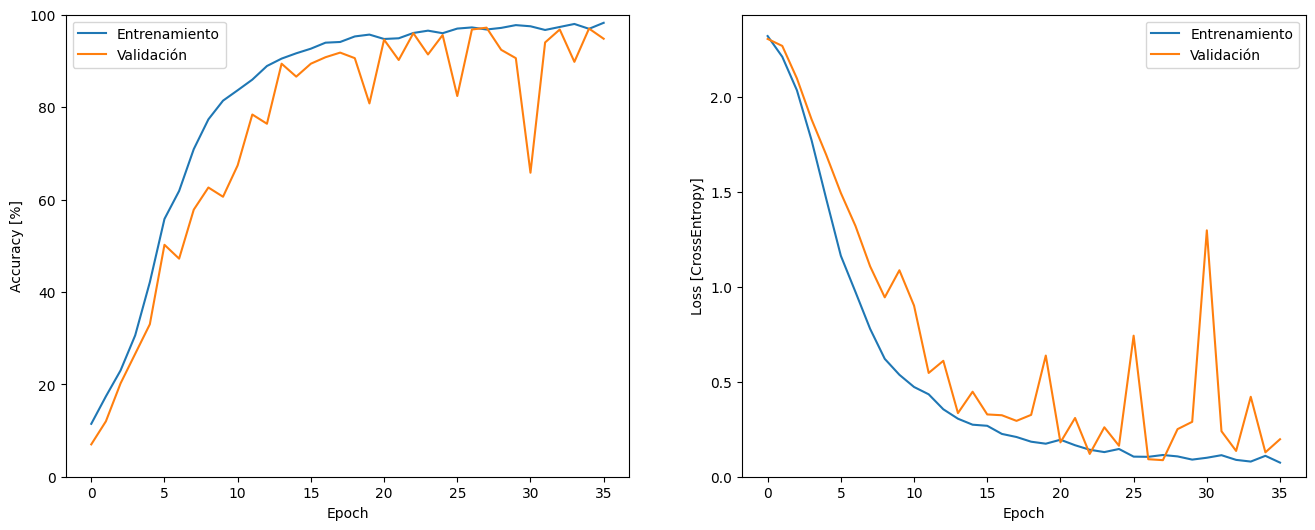

In [ ]:
metrics = history_rnn.history

plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.plot(history_rnn.epoch, 100*np.array(metrics['accuracy']), 100*np.array(metrics['val_accuracy']))
plt.legend(['Entrenamiento', 'Validación'])
plt.ylim([0, 100])
plt.xlabel('Epoch')
plt.ylabel('Accuracy [%]')

plt.subplot(1,2,2)
plt.plot(history_rnn.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['Entrenamiento', 'Validación'])
plt.ylim([0, max(plt.ylim())])
plt.xlabel('Epoch')
plt.ylabel('Loss [CrossEntropy]')

plt.show()

Utilizamos una matriz de confusión para verificar qué tan bien clasificó el modelo cada uno de los comandos en el conjunto de prueba:

In [ ]:
y_pred_rnn = model_rnn.predict(val_spectrogram_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


In [ ]:
y_pred_rnn = tf.argmax(y_pred_rnn, axis=1)

In [ ]:
y_true = tf.concat(list(val_spectrogram_ds.map(lambda s,lab: lab)), axis=0)

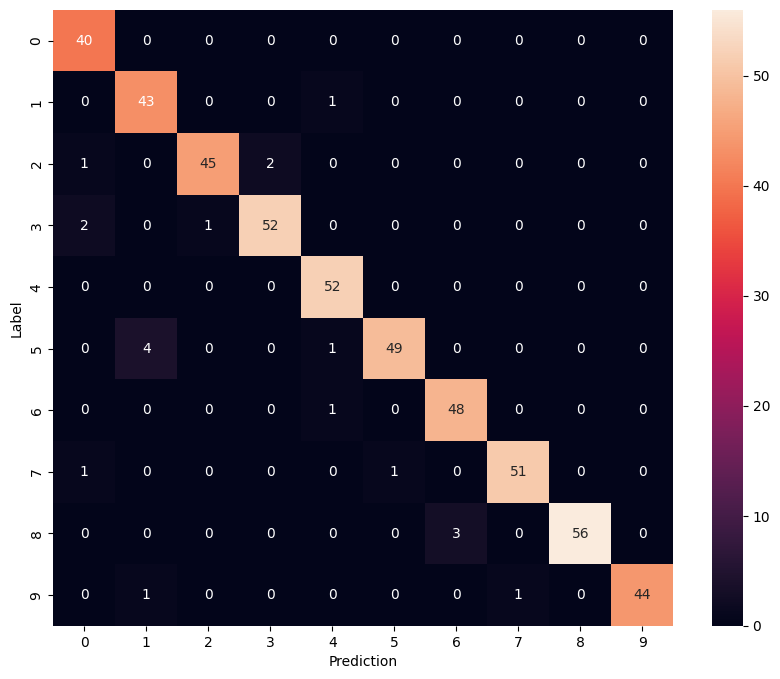

In [ ]:
confusion_mtx_rnn = tf.math.confusion_matrix(y_true, y_pred_rnn)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx_rnn,
            xticklabels=label_names,
            yticklabels=label_names,
            annot=True, fmt='g')
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()

#### Inferir sobre un archivo de audio

Finalmente, inferimos sobre un archivo de audio (en este caso tomamos un archivo del dataset arbitrario, podría ser un archivo .wav completamente nuevo).

Archivo seleccionado: /content/spoken_digit_audio/3/927.wav


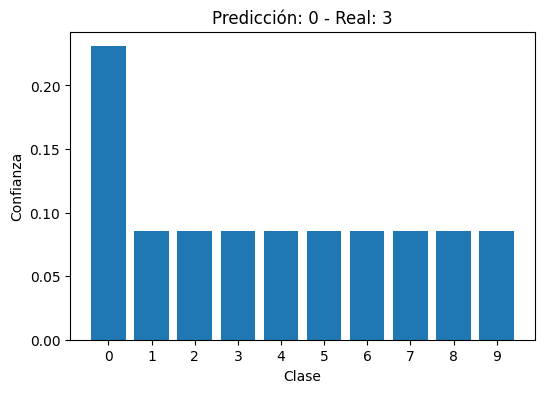

In [ ]:
predecir_audio_aleatorio(model_rnn, data_dir, label_names, get_spectrogram)

## Conclusiones

Imprimimos en pantalla las métricas de los modelos de CNN y RNN para poder realizar una comparativa.

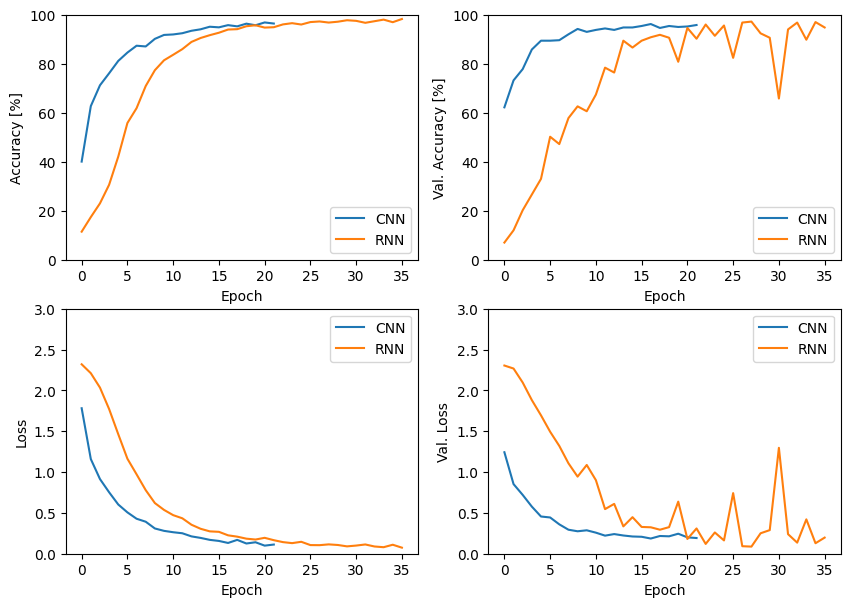

In [ ]:
metrics_cnn = history_cnn.history
metrics_rnn = history_rnn.history

plt.figure(figsize=(10,7))

plt.subplot(2,2,1)
plt.plot(history_cnn.epoch, 100*np.array(metrics_cnn['accuracy']), 100*np.array(metrics_rnn['accuracy']))
plt.legend(['CNN', 'RNN'])
plt.ylim([0, 100])
plt.xlabel('Epoch')
plt.ylabel('Accuracy [%]')

plt.subplot(2,2,2)
plt.plot(history_cnn.epoch, 100*np.array(metrics_cnn['val_accuracy']), 100*np.array(metrics_rnn['val_accuracy']))
plt.legend(['CNN', 'RNN'])
plt.ylim([0, 100])
plt.xlabel('Epoch')
plt.ylabel('Val. Accuracy [%]')

plt.subplot(2,2,3)
plt.plot(history_cnn.epoch, metrics_cnn['loss'], metrics_rnn['loss'])
plt.legend(['CNN', 'RNN'])
plt.ylim([0, 3])
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(2,2,4)
plt.plot(history_cnn.epoch, metrics_cnn['val_loss'], metrics_rnn['val_loss'])
plt.legend(['CNN', 'RNN'])
plt.ylim([0, 3])
plt.xlabel('Epoch')
plt.ylabel('Val. Loss')

plt.show()

Si bien el RNN tarda más épocas que el CNN en converger a su valor final de Accuracy y Loss (comienza desde una métrica peor también), en todas las iteraciones que hemos probado ha logrado alcanzar resultados ligeramente mejores (~98% para el RNN vs. ~95% para el CNN). Sin embargo, las métricas de validación del RNN se ven más "inestables", con variaciones bruscas hasta alcanzar su valor final.

Imprimiendo ambas matrices de confusión, se observa algo similar.

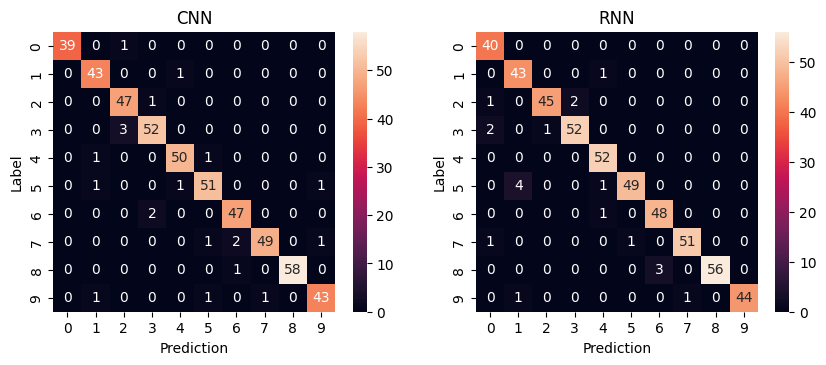

In [ ]:
plt.figure(figsize=(10, 8))

plt.subplot(2,2,1)
sns.heatmap(confusion_mtx_cnn,
            xticklabels=label_names,
            yticklabels=label_names,
            annot=True, fmt='g')
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.title('CNN')

plt.subplot(2,2,2)
sns.heatmap(confusion_mtx_rnn,
            xticklabels=label_names,
            yticklabels=label_names,
            annot=True, fmt='g')
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.title('RNN')

plt.show()

Se presentan muy pocas clasificaciones erróneas en ambos casos, concentrándose casi todas sobre la diagonal.

En vista de los resultados, se podría decir que la mejora de la RNN frente al CNN es marginal y no se podría asegurar que es un mejor método para modelar este problema (se podría seguir experimentando con la cantidad de capas o convoluciones y quizá alcanzar mejores resultados con el CNN, por ejemplo). Sin embargo, un parámetro para comparar ambos modelos podría ser su complejidad, ya que esto influye sobre el costo computacional.

Observando la cantidad de parámetros de ambos modelos, rápidamente se detecta que el modelo que hace uso de RNN tiene casi 3 veces menos parámetros que el modelo que hace uso de CNN. Por lo tanto, podríamos decir que el modelo basado en RNN resulta ser un mejor modelo que el que se basa en CNN, por su desempeño ligeramente mejor y su mejor aprovechamiento de recursos computacionales.